In [8]:
import pandas as pd
import numpy as np
import warnings
import yfinance as yf
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [2]:
# main variables
tickers= ['AAPL','MSFT','GOOG','AMZN','TSLA','NVDA']
period= "5y"
#number of simulations
num_sim = 10000

# Data Collection

def get_data(tickers, period):
    print(f"Downloading data for: {tickers}...")
    data= yf.download(tickers, period= period, auto_adjust= "True")["Close"]
    df_main =data.dropna()
    return df_main

In [3]:
# Analysis Part

def run_simulation(df):
    #log returns for time additivity
    log_returns= np.log(df/df.shift(1).dropna())

    #anuallise statistics
    trade_days= 252
    mean_returns= log_returns.mean()*trade_days
    cov_matrix= log_returns.cov()*trade_days

    # monte carlo simulations
    num_assets= len(df.columns)

    #initialise array
    all_weights = np.zeros((num_sim, num_assets))
    ret_arr = np.zeros(num_sim)
    vol_arr = np.zeros(num_sim)
    sharpe_arr = np.zeros(num_sim)
    print (f"Simulating{num_sim} portfolio combinations...")

    for i in range (num_sim):
        #  random weight generation
        weights =np.random.random(num_assets)
        weights= weights/np.sum(weights)
        # for normalisation, sum= 1(100%)
        all_weights[i,:]= weights

        # portfolio returns
        ret_arr[i]= np.sum(mean_returns*weights)
        # calculate volatility (Std. Deviation)
        vol_arr[i]= np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

        # calculate Sharpe Ratio, assume Risk free ratio - 0
        sharpe_arr[i]= ret_arr[i]/ vol_arr[i]

    return all_weights, ret_arr, vol_arr, sharpe_arr

In [6]:
# Execution

if __name__== "__main__":
    try:
        prices= pd.read_csv("stock_prices.csv", parse_dates= True, index_col="Date")
        print("Loaded data from local.csv")
    except FileNotFoundError:
        prices= get_data(tickers, period)
        prices.to_csv("stock_prices.csv")
        print("Data downloaded and saved to CSV.")

weights, returns, volatility, sharpe_ratios = run_simulation(prices)

# optimal Portfolio
max_sharpe_idx= sharpe_ratios.argmax()
max_sr_ret= returns[max_sharpe_idx]
max_sr_vol= volatility[max_sharpe_idx]
max_sr_sharpe= sharpe_ratios[max_sharpe_idx]

print("\n"+ "="*40)
print("Optimal Portfolio Allocation")
print("="*40)
print(f"{'ticker':<10}{'Allocation':>10}")
print("-"*25)

optimal_weights= weights[max_sharpe_idx,:]
for i, ticker in enumerate(prices.columns):
    print(f"{ticker:<10}{optimal_weights[i]:.2%}")

print("-"*25)
print(f"Expected Return: {max_sr_ret:.2%}")
print(f"Annual Risk: {max_sr_vol:.2%}")
print(f"Sharpe Ratio: {max_sr_sharpe:.2%}")
print("="*40)

[*********************100%***********************]  6 of 6 completed


Data downloaded and saved to CSV.
Simulating10000 portfolio combinations...

Optimal Portfolio Allocation
ticker    Allocation
-------------------------
AAPL      23.00%
AMZN      7.25%
GOOG      16.21%
MSFT      3.04%
NVDA      49.91%
TSLA      0.59%
-------------------------
Expected Return: 30.31%
Annual Risk: 34.88%
Sharpe Ratio: 86.89%


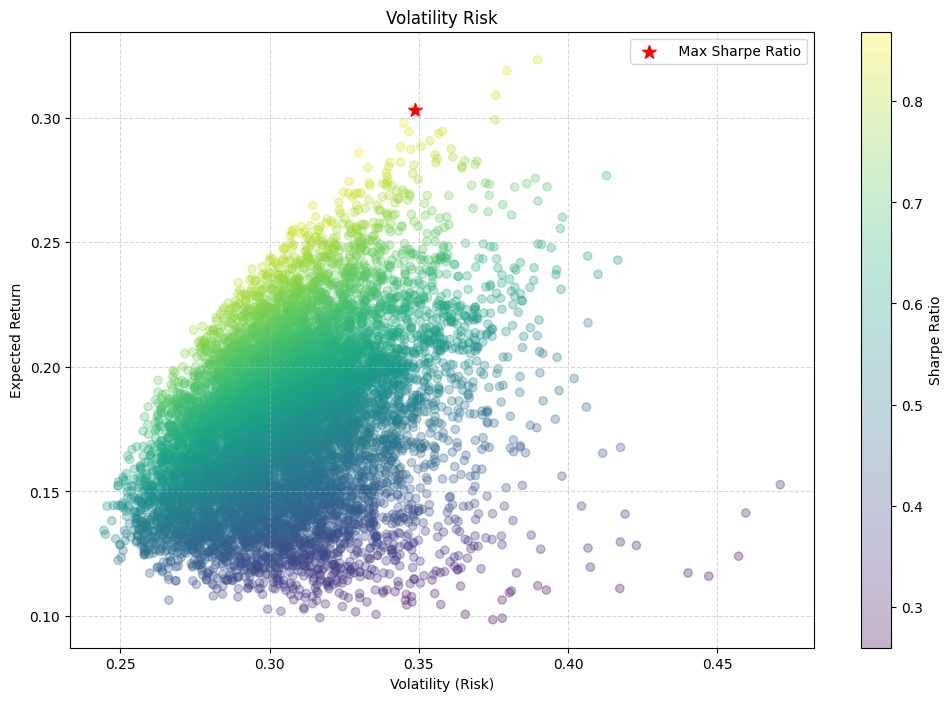

In [9]:
# Visualisation

plt.figure(figsize=(12,8))
plt.scatter(volatility, returns, c= sharpe_ratios, cmap='viridis', alpha=0.3)
plt.colorbar(label="Sharpe Ratio")

#marking the optimal portfolio with red star
plt.scatter(max_sr_vol, max_sr_ret, c="red", s=100, marker='*', label= ' Max Sharpe Ratio')
plt.title("Volatility Risk")
plt.ylabel("Expected Return")
plt.xlabel("Volatility (Risk)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
# Part 2: How Wrong Could `mean_returns` and `cov_matrix` Be?
### MLE, Bootstrap Confidence Intervals, and Weight Instability

Everything above treats `mean_returns` and `cov_matrix` as if they were the
true parameters and searches for the "optimal" portfolio against them. But
they're just **MLE point estimates from ~5 years of daily returns** — they
carry real sampling error. This section:

1. Re-derives `mean_returns`/`cov_matrix` explicitly as MLEs (and checks them
   against what you already computed above).
2. Builds **bootstrap confidence intervals** around them.
3. Re-runs the **same max-Sharpe optimization** on every bootstrap resample.
4. Shows how much the "optimal" weights swing around, purely from resampling
   noise on the same 6-asset history.

That instability is the quantitative case for **Black-Litterman**: instead of
feeding a noisy point-estimate `mu` straight into an optimizer, BL blends a
stable equilibrium prior with your views before optimizing — shrinking the
input rather than amplifying its noise.

Run this after the cells above have executed (needs `prices`, `tickers`,
`optimal_weights` from your simulation).


## 2.1 Recover inputs at notebook level

`log_returns`, `mean_returns`, and `cov_matrix` are local to `run_simulation()` above, so recompute them here from `prices` (same formulas your function uses).

In [ ]:
log_returns = np.log(prices / prices.shift(1)).dropna()
trade_days = 252
mean_returns = log_returns.mean() * trade_days
cov_matrix = log_returns.cov() * trade_days
tickers = list(prices.columns)
n_assets = len(tickers)

print(f"{len(log_returns)} daily log-return observations, {n_assets} assets: {tickers}")


## 2.2 MLE Point Estimates

$$\hat\mu = \frac{1}{T}\sum_t r_t \qquad
\hat\Sigma = \frac{1}{T}\sum_t (r_t-\hat\mu)(r_t-\hat\mu)^\top$$

Note: the MLE covariance divides by $T$ (not $T-1$ like pandas' `.cov()`
default). The mean is identical either way — only the covariance differs
slightly. We use the MLE (`ddof=0`) version from here on for consistency.


In [ ]:
def mle_mu_cov(R, annualize=252):
    """MLE mean vector and covariance matrix from a T x N log-return matrix."""
    T = R.shape[0]
    mu_hat = R.mean(axis=0)
    centered = R - mu_hat
    cov_hat = (centered.T @ centered) / T  # MLE: divide by T, not T-1
    return mu_hat * annualize, cov_hat * annualize

R = log_returns.values
mu_hat, cov_hat = mle_mu_cov(R)

mu_check = pd.DataFrame({
    'MLE mean (this section)': mu_hat,
    'mean_returns (Part 1, identical)': mean_returns.values,
}, index=tickers)
mu_check.round(4)


In [ ]:
cov_diag_check = pd.DataFrame({
    'MLE variance, ddof=0 (this section)': np.diag(cov_hat),
    'cov_matrix variance, ddof=1 (Part 1)': np.diag(cov_matrix.values),
}, index=tickers)
cov_diag_check.round(5)


## 2.3 Bootstrap Confidence Intervals

Nonparametric bootstrap: resample the daily log-return history with
replacement $B$ times, recompute $\hat\mu,\hat\Sigma$ on each resample, and
use the empirical distribution for percentile CIs. No normality assumption
beyond "the historical sample represents the return-generating process."


In [ ]:
B = 2000  # bootstrap resamples
T = R.shape[0]
rng = np.random.default_rng(7)

boot_mu = np.zeros((B, n_assets))
boot_cov = np.zeros((B, n_assets, n_assets))

for b in range(B):
    idx = rng.integers(0, T, size=T)
    mu_b, cov_b = mle_mu_cov(R[idx])
    boot_mu[b] = mu_b
    boot_cov[b] = cov_b

print(f"Ran {B} bootstrap resamples of {T} daily observations each.")


In [ ]:
ci_lower = np.percentile(boot_mu, 2.5, axis=0)
ci_upper = np.percentile(boot_mu, 97.5, axis=0)

ci_table = pd.DataFrame({
    'MLE mean': mu_hat,
    '95% CI lower': ci_lower,
    '95% CI upper': ci_upper,
    'CI width': ci_upper - ci_lower
}, index=tickers)
ci_table.round(4)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_assets)
ax.errorbar(x, mu_hat, yerr=[mu_hat - ci_lower, ci_upper - mu_hat],
            fmt='o', capsize=6, markersize=8, color='C0')
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_ylabel('Annualized expected log return')
ax.set_title(f'Bootstrap 95% CIs for Expected Returns\n({T} obs, {B} resamples)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('mean_return_cis_real.png', dpi=150)
plt.show()


Same exercise for volatility, to compare how precisely means vs. vols are estimated.

In [ ]:
boot_vol = np.sqrt(np.diagonal(boot_cov, axis1=1, axis2=2))
vol_hat = np.sqrt(np.diag(cov_hat))

vol_ci_lower = np.percentile(boot_vol, 2.5, axis=0)
vol_ci_upper = np.percentile(boot_vol, 97.5, axis=0)

vol_table = pd.DataFrame({
    'MLE vol': vol_hat,
    '95% CI lower': vol_ci_lower,
    '95% CI upper': vol_ci_upper,
    'CI width': vol_ci_upper - vol_ci_lower
}, index=tickers)
vol_table.round(4)


In [ ]:
rel_width_mu = (ci_upper - ci_lower) / np.abs(mu_hat)
rel_width_vol = (vol_ci_upper - vol_ci_lower) / vol_hat

comparison = pd.DataFrame({
    'Relative CI width: mean': rel_width_mu,
    'Relative CI width: vol': rel_width_vol
}, index=tickers)
comparison.round(2)


If `Relative CI width: mean` comes out much larger than `Relative CI width: vol` for your tickers, that's the standard result: expected returns are estimated far less precisely than volatilities from the same sample.

## 2.4 Exact Max-Sharpe Optimizer (cross-check vs. your Monte Carlo search)

Your random-search Monte Carlo (10,000 draws) approximates the tangency
portfolio. Here we solve for it exactly with `scipy.optimize` (SLSQP), long-only,
fully invested, same Sharpe convention (`rf = 0`) as Part 1. This exact solver
is what we'll re-run on every bootstrap resample — 2,000 random-weight
Monte Carlo runs would be far too slow, but SLSQP converges in milliseconds.


In [ ]:
from scipy.optimize import minimize

r_f = 0.0  # matches the risk-free assumption used in Part 1

def neg_sharpe(w, mu, cov, rf=r_f):
    ret = w @ mu
    vol = np.sqrt(w @ cov @ w)
    return -(ret - rf) / vol

def max_sharpe_weights(mu, cov, rf=r_f):
    n = len(mu)
    w0 = np.ones(n) / n
    bounds = [(0.0, 1.0)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    res = minimize(neg_sharpe, w0, args=(mu, cov, rf), method='SLSQP',
                    bounds=bounds, constraints=constraints,
                    options={'maxiter': 500, 'ftol': 1e-10})
    return res.x

w_hat = max_sharpe_weights(mu_hat, cov_hat)

sanity_check = pd.DataFrame({
    'Your Monte Carlo optimum (10k random portfolios)': optimal_weights,
    'SLSQP exact optimum (same mu_hat/cov_hat)': w_hat
}, index=tickers)
sanity_check.round(4)


These two columns should be close (SLSQP is exact, so it may differ a bit from the discretized Monte Carlo grid — that's expected and a nice sanity check on Part 1's simulation).

## 2.5 Weight Instability: Propagating Estimation Error Through the Optimizer

For every one of the $B$ bootstrap resamples in Section 2.3, we already have a
$(\hat\mu_b, \hat\Sigma_b)$ pair. Re-run the identical optimizer on each pair
and collect the resulting weight vectors. If mean-variance optimization were
robust to estimation noise, the weights would cluster tightly around
`w_hat`. Watch how much they actually swing.


In [ ]:
boot_weights = np.zeros((B, n_assets))
failed = 0
for b in range(B):
    try:
        boot_weights[b] = max_sharpe_weights(boot_mu[b], boot_cov[b])
    except Exception:
        boot_weights[b] = np.nan
        failed += 1

print(f"Optimizer failed on {failed}/{B} resamples (excluded).")
valid = ~np.isnan(boot_weights).any(axis=1)
boot_weights = boot_weights[valid]


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot([boot_weights[:, i] for i in range(n_assets)],
                 labels=tickers, showfliers=True, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#a6c8ff')
ax.scatter(np.arange(1, n_assets + 1), w_hat, color='red', marker='D',
           zorder=5, label='Point-estimate optimal weight')
ax.set_ylabel('Portfolio weight')
ax.set_title(f'Max-Sharpe Weight Distribution Across {len(boot_weights)} Bootstrap Resamples\n'
             f'{tickers} — same 5y history, instability is purely estimation noise')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('weight_instability_boxplot_real.png', dpi=150)
plt.show()


In [ ]:
weight_stats = pd.DataFrame({
    'Point estimate weight': w_hat,
    'Bootstrap mean weight': boot_weights.mean(axis=0),
    'Bootstrap std dev': boot_weights.std(axis=0),
    'Bootstrap 5th pct': np.percentile(boot_weights, 5, axis=0),
    'Bootstrap 95th pct': np.percentile(boot_weights, 95, axis=0),
}, index=tickers)
weight_stats['Coefficient of variation'] = (
    weight_stats['Bootstrap std dev'] / weight_stats['Bootstrap mean weight'].replace(0, np.nan)
)
weight_stats.round(4)


## 2.6 Decomposing the Instability: $\mu$-noise vs. $\Sigma$-noise

Redo the exercise twice more: perturb only $\mu$ (hold $\Sigma$ fixed at
`cov_hat`), then perturb only $\Sigma$ (hold $\mu$ fixed at `mu_hat`). This
isolates which estimation error is actually driving the weight swings.


In [ ]:
weights_mu_only = np.array([max_sharpe_weights(boot_mu[b], cov_hat) for b in range(B)])
weights_cov_only = np.array([max_sharpe_weights(mu_hat, boot_cov[b]) for b in range(B)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

axes[0].boxplot([weights_mu_only[:, i] for i in range(n_assets)], labels=tickers, patch_artist=True,
                 boxprops=dict(facecolor='#ffb3b3'))
axes[0].set_title('Weight variation from $\\hat\\mu$ noise only\n($\\Sigma$ fixed)')
axes[0].set_ylabel('Portfolio weight')

axes[1].boxplot([weights_cov_only[:, i] for i in range(n_assets)], labels=tickers, patch_artist=True,
                 boxprops=dict(facecolor='#b3e6b3'))
axes[1].set_title('Weight variation from $\\hat\\Sigma$ noise only\n($\\mu$ fixed)')

plt.suptitle(f'Decomposing Weight Instability by Input Source — {tickers}')
plt.tight_layout()
plt.savefig('weight_instability_decomposed_real.png', dpi=150)
plt.show()

print('Average weight std dev, mu-noise-only:  ', weights_mu_only.std(axis=0).mean().round(4))
print('Average weight std dev, cov-noise-only: ', weights_cov_only.std(axis=0).mean().round(4))


## 2.7 Takeaways → Why Black-Litterman

1. **Bootstrap CIs on `mean_returns` are wide** relative to the spread across
   your six tickers — expected returns from ~5 years of data are noisy estimates,
   not precise ones.
2. **Bootstrap CIs on volatility are comparatively tight** — the second moment
   is estimated far more precisely than the first, same sample size.
3. **The optimizer amplifies input noise into weight noise**: re-running the
   identical max-Sharpe solve on bootstrap resamples of the *same* 6-stock
   history produces very different "optimal" allocations — see the boxplot
   in 2.5, and compare its spread to the tight `optimal_weights` point
   estimate your Part 1 Monte Carlo reported.
4. **Section 2.6 shows the instability is driven mostly by $\mu$-estimation
   error**, not $\Sigma$-estimation error — confirming the optimizer amplifies
   noise specifically in the input you can least reliably estimate.
5. This is the empirical case for **Black-Litterman**: rather than feeding the
   noisy sample `mean_returns` straight into MVO, BL starts from a stable
   market-equilibrium prior (via reverse optimization on market-cap weights)
   and blends in your views weighted by their own uncertainty — shrinking the
   input before it ever reaches the optimizer, instead of amplifying its noise.

**Next (L3 project):** implement Black-Litterman on this same 6-ticker set,
feed the BL posterior `mu`/`cov` into the identical `max_sharpe_weights()`
optimizer used here, and re-run the Section 2.5 bootstrap-resampling exercise
to show BL weights are materially more stable than the MVO weights above.
